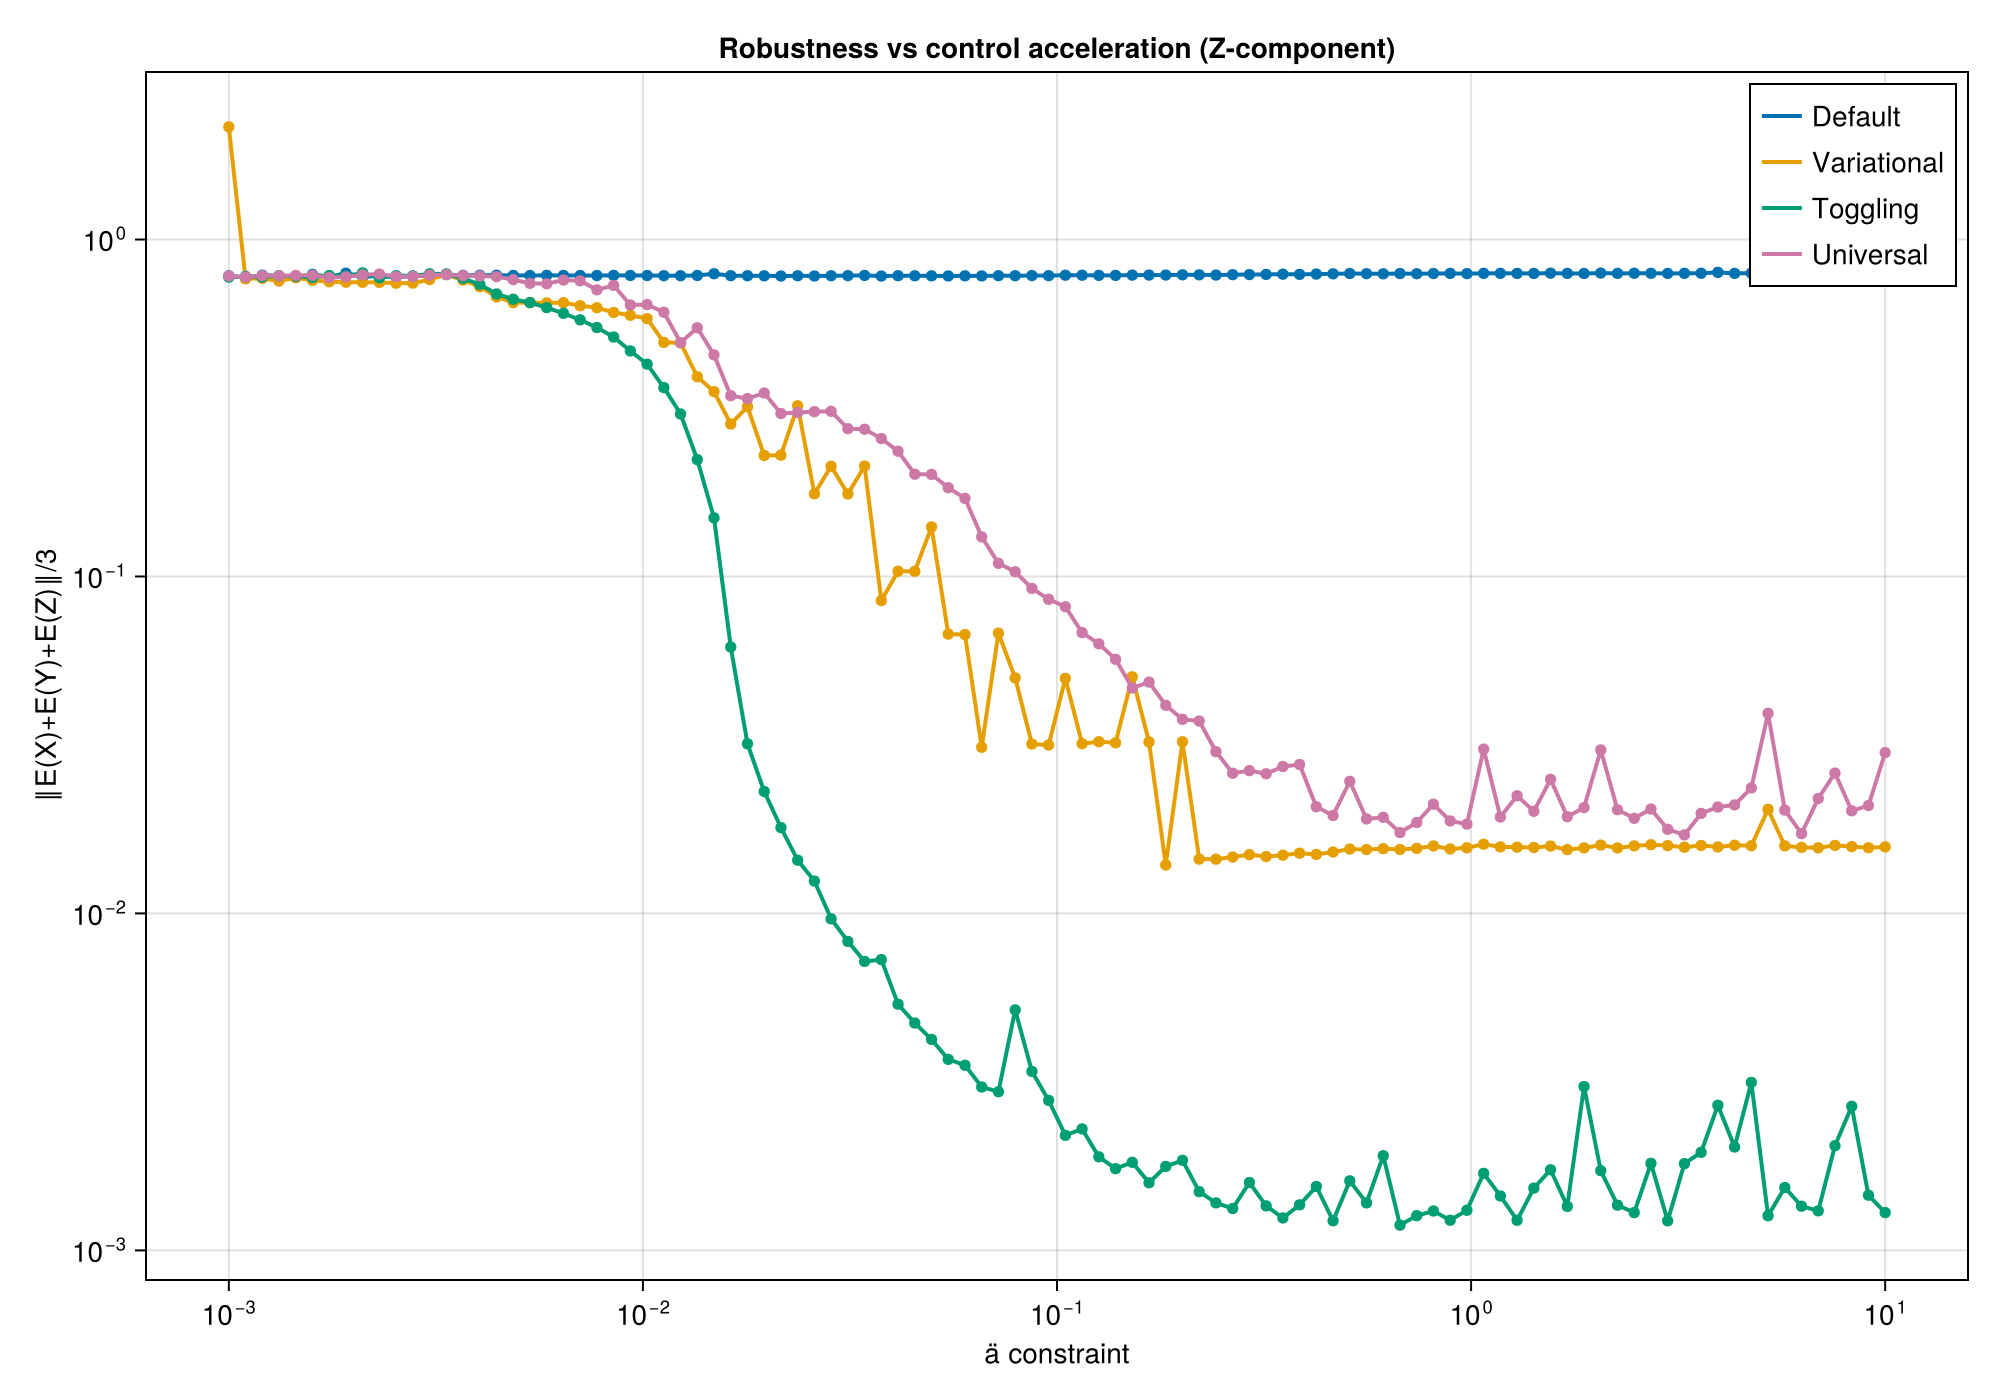

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [9]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:35
dfs = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(X)+E(Y)+E(Z)‖/3",
    xscale = log10,
    yscale = log10,
    title  = "Robustness vs control acceleration (Z-component)",
)

function draw!(y, color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_linear.png", fig; px_per_unit=2)

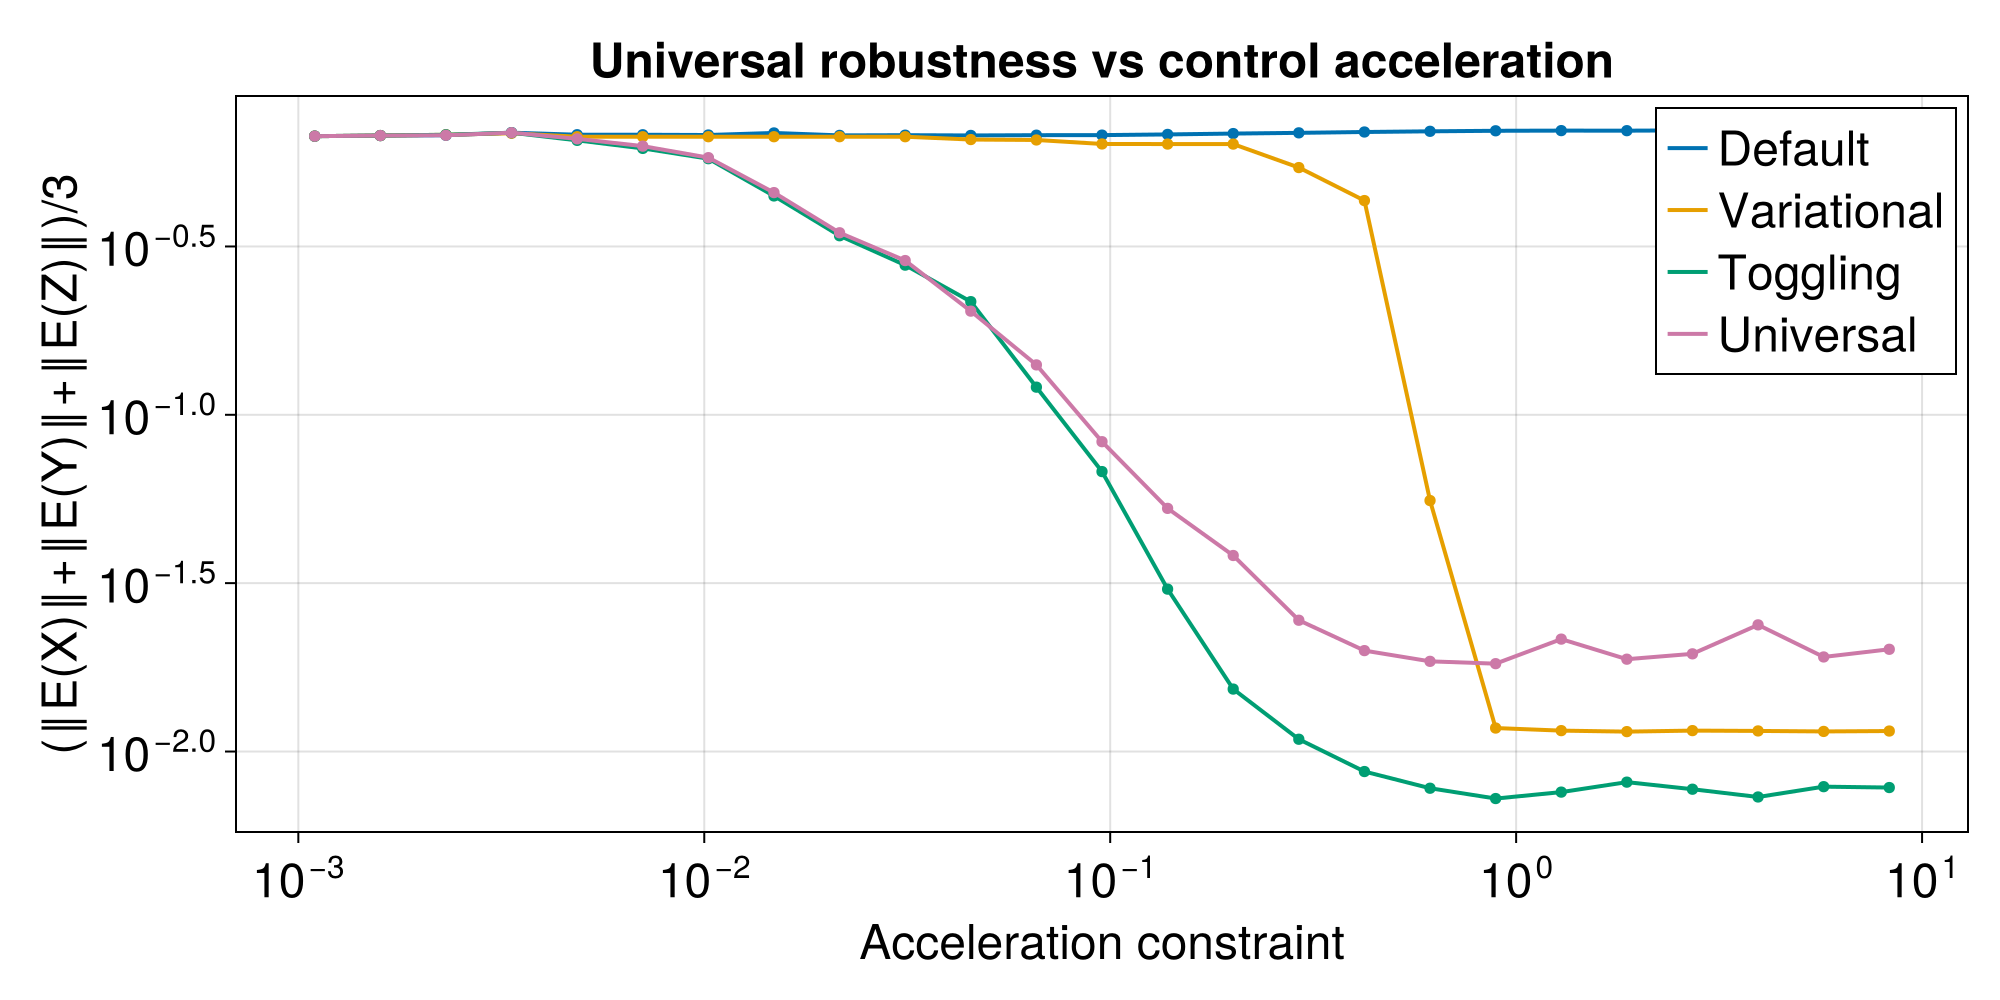

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


In [44]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:40
dfs = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def)
Y_var = stackcol(:norm_G_var)
Y_add = stackcol(:norm_G_add)
Y_uni = stackcol(:norm_G_uni)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 500))
ax  = CM.Axis(fig[1, 1];
    xlabel = "Acceleration constraint",
    ylabel = "(‖E(X)‖+‖E(Y)‖+‖E(Z)‖)/3",
    xscale = log10,
    yscale = log10,
    title  = "Universal robustness vs control acceleration",
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 24,
    xticklabelsize = 24,
    yticklabelsize = 24,
)

# Plot only every 2nd point (1, 3, 5, ...)
const IDX = 2:4:length(x)

function draw!(y, color, label)
    CM.lines!(ax, x[IDX], y[IDX]; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x[IDX], y[IDX]; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt, labelsize=24)

display(fig)
save("dda_constraint_uni_paper.png", fig; px_per_unit=2)

In [ ]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load universal data ----------
seed_range = 1:1
dfs = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_Q_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def)
Y_var = stackcol(:norm_G_var)
Y_add = stackcol(:norm_G_add)
Y_uni = stackcol(:norm_G_uni)

mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Load dephasing data ----------
dfs_dephasing = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_dephasing_Q_seed_$(i).csv"
    isfile(fn) && push!(dfs_dephasing, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs_dephasing) "No dephasing CSV files were loaded."

x_dephasing = collect(dfs_dephasing[1].ä_vals)
stackcol_dephasing(sym) = reduce(hcat, (df[!, sym] for df in dfs_dephasing))

Y_def_z = stackcol_dephasing(:norm_G_def_z)
Y_var_z = stackcol_dephasing(:norm_G_var_z)
Y_add_z = stackcol_dephasing(:norm_G_add_z)
Y_uni_z = stackcol_dephasing(:norm_G_uni_z)

mean_def_z = mean(Y_def_z; dims=2)[:]
mean_var_z = mean(Y_var_z; dims=2)[:]
mean_add_z = mean(Y_add_z; dims=2)[:]
mean_uni_z = mean(Y_uni_z; dims=2)[:]

# ---------- Create subplots ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 1000))

# First subplot (a)
ax1 = CM.Axis(fig[1, 1];
    xlabel = "Acceleration constraint",
    ylabel = "(‖E(X)‖+‖E(Y)‖+‖E(Z)‖)/3",
    xscale = log10,
    yscale = log10,
    title = "Universal robustness vs control acceleration",
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 24,
    xticklabelsize = 24,
    yticklabelsize = 24,
)

const IDX = 1:1:length(x)

function draw!(ax, x_data, y, color, label)
    CM.lines!(ax, x_data[IDX], y[IDX]; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x_data[IDX], y[IDX]; color=color, marker=:circle, markersize=8)
end

draw!(ax1, x, mean_def, colors[1], labels[1])
draw!(ax1, x, mean_var, colors[2], labels[2])
draw!(ax1, x, mean_add, colors[3], labels[3])
draw!(ax1, x, mean_uni, colors[4], labels[4])

CM.axislegend(ax1; position=:rt, labelsize=24)

# Add (a) label to top-left of first subplot
CM.Label(fig[1, 1, TopLeft()], "(a)", fontsize=32, halign=:left, valign=:top, 
         padding=(10, 0, -10, 0), tellwidth=false, tellheight=false)

# Second subplot (b)
ax2 = CM.Axis(fig[2, 1];
    xlabel = "Acceleration constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title = "Dephasing robustness vs control acceleration",
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 24,
    xticklabelsize = 24,
    yticklabelsize = 24,
)

const IDX2 = 1:1:length(x_dephasing)

draw!(ax2, x_dephasing, mean_def_z, colors[1], labels[1])
draw!(ax2, x_dephasing, mean_var_z, colors[2], labels[2])
draw!(ax2, x_dephasing, mean_add_z, colors[3], labels[3])
draw!(ax2, x_dephasing, mean_uni_z, colors[4], labels[4])

CM.axislegend(ax2; position=:rt, labelsize=24)

# Add (b) label to top-left of second subplot
CM.Label(fig[2, 1, TopLeft()], "(b)", fontsize=32, halign=:left, valign=:top, 
         padding=(10, 0, -10, 0), tellwidth=false, tellheight=false)

display(fig)
#save("dda_constraint.png", fig; px_per_unit=2)

  Activating 

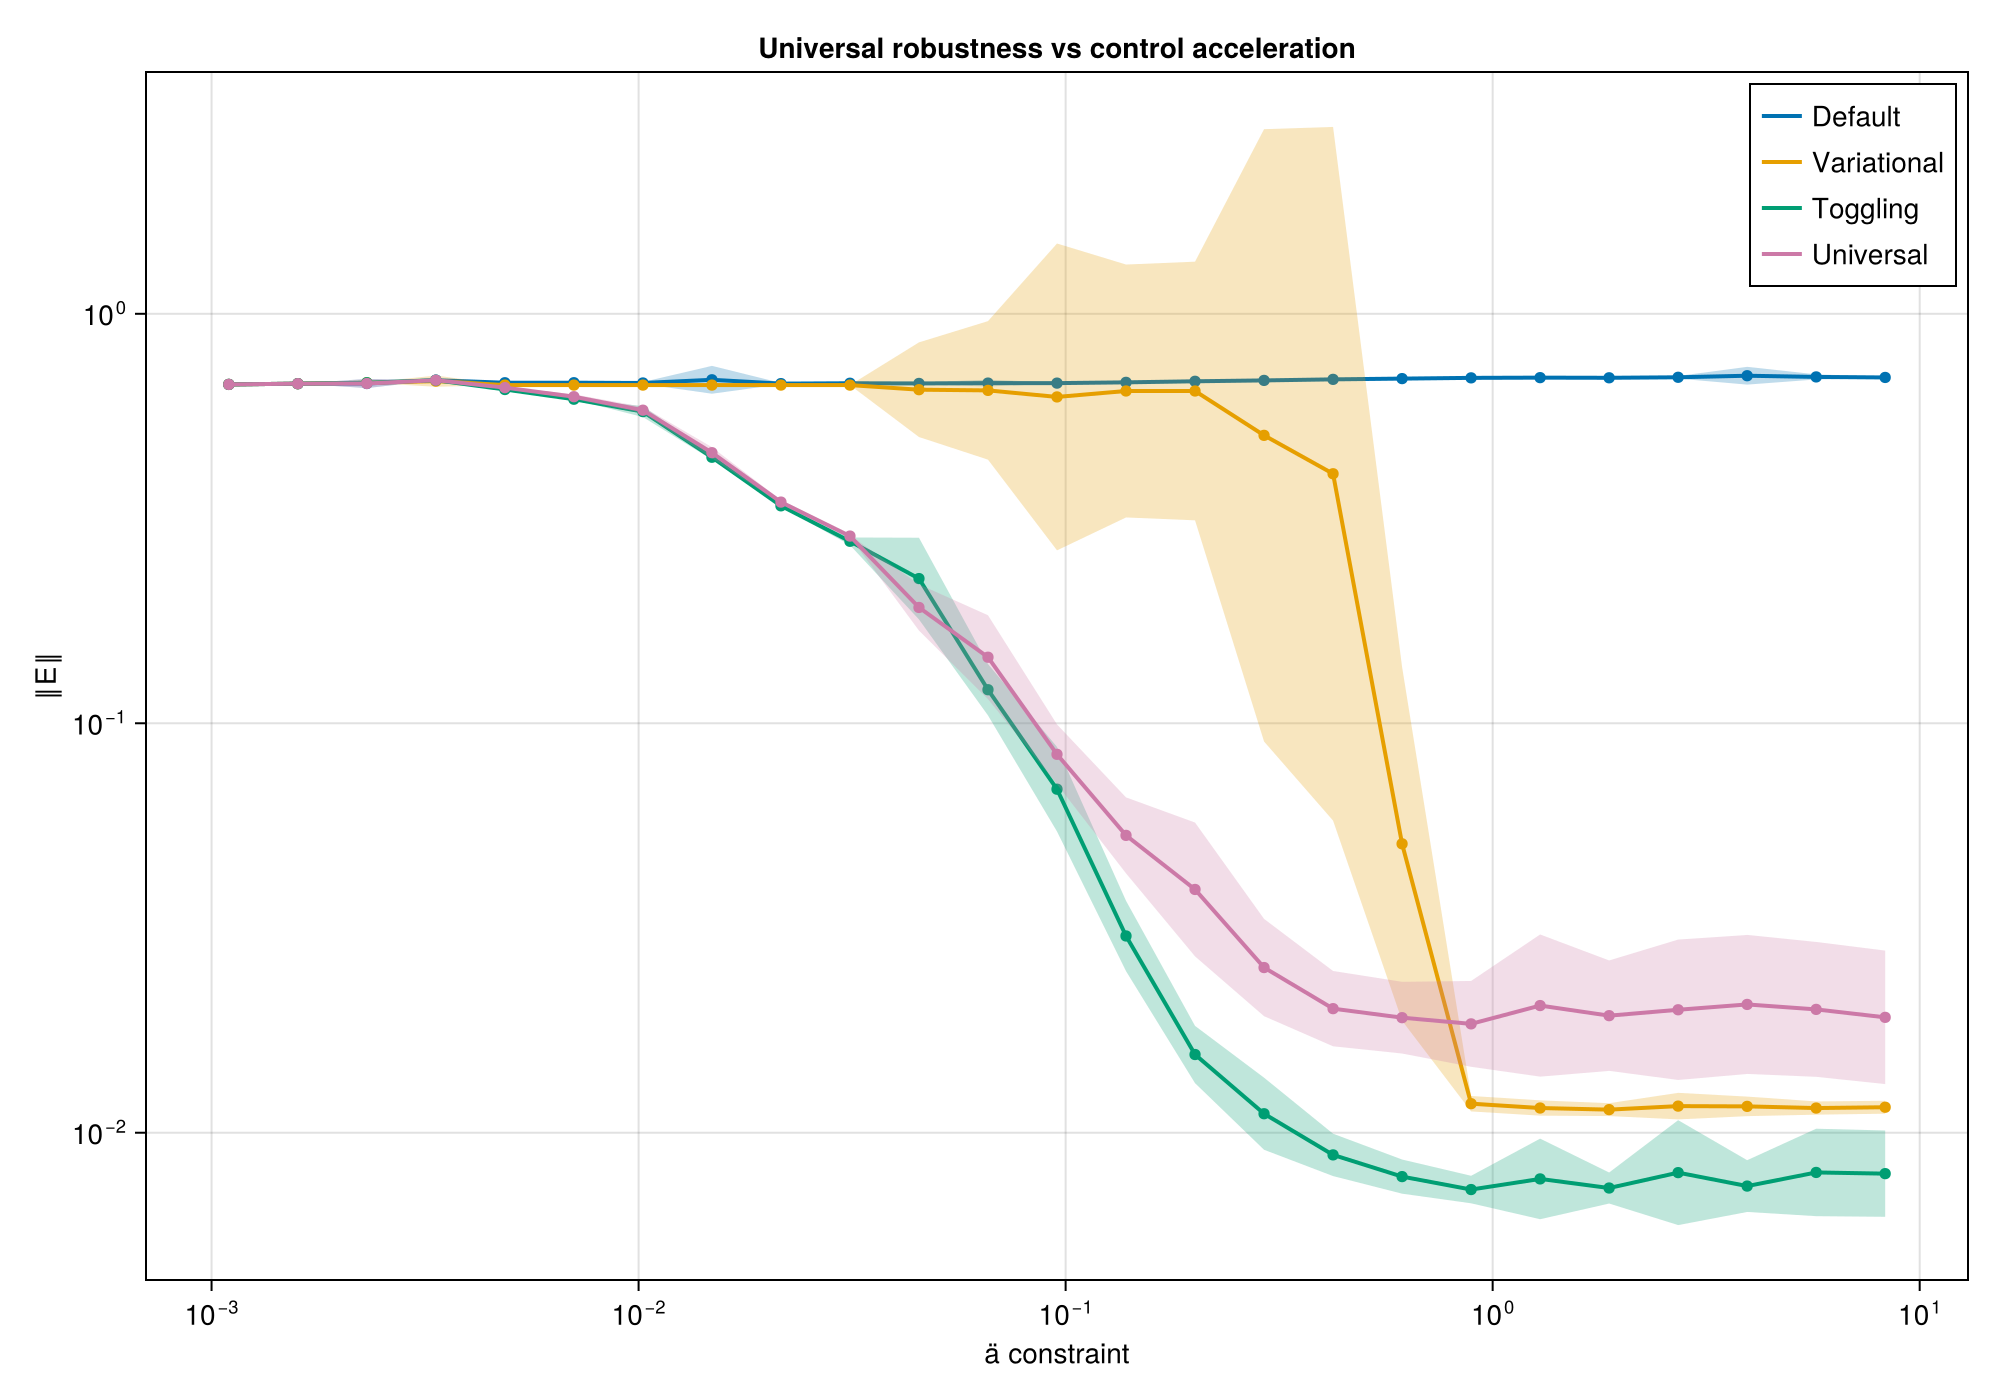

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


In [ ]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:30
dfs = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x_all = collect(dfs[1].ä_vals)
@assert all(isequal(x_all), (collect(df.ä_vals) for df in dfs))
@assert all(x_all .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def)
Y_var = stackcol(:norm_G_var)
Y_add = stackcol(:norm_G_add)
Y_uni = stackcol(:norm_G_uni)

# ---------- Stats helper (mean in linear space, ±σ band symmetric on log scale) ----------
# Keeps only rows where all seeds > 0 (required for log scales).
# Thins to every 4th point starting at 2 to reduce clutter (2, 6, 10, ...).
function series_stats_for_plot(x::AbstractVector, Y::AbstractMatrix)
    row_ok = mapslices(r -> all(r .> 0), Y; dims=2)[:]
    x2 = x[row_ok]
    Y2 = Y[row_ok, :]

    μ  = mean(Y2; dims=2)[:]                # arithmetic mean (as requested)
    LY = log10.(Y2)                         # for uncertainty on log scale
    σL = std(LY; dims=2)[:]                 # std in log10 space

    μL = log10.(μ)
    lo = 10 .^ (μL .- σL)                   # lower band (log-symmetric)
    hi = 10 .^ (μL .+ σL)                   # upper band

    idx = 2:4:length(x2)                    # thin points: 2,6,10,...
    return x2[idx], μ[idx], lo[idx], hi[idx]
end

x_def, μ_def, lo_def, hi_def = series_stats_for_plot(x_all, Y_def)
x_var, μ_var, lo_var, hi_var = series_stats_for_plot(x_all, Y_var)
x_add, μ_add, lo_add, hi_add = series_stats_for_plot(x_all, Y_add)
x_uni, μ_uni, lo_uni, hi_uni = series_stats_for_plot(x_all, Y_uni)

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E‖",
    xscale = log10,
    yscale = log10,
    title  = "Universal robustness vs control acceleration",
)

# Draw helper: shaded band (±σ in log space) + mean line + dots
function draw!(ax, x, μ, lo, hi, color, label)
    CM.band!(ax, x, lo, hi; color=(color, 0.25))
    CM.lines!(ax, x, μ; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, μ; color=color, marker=:circle, markersize=8)
end

draw!(ax, x_def, μ_def, lo_def, hi_def, colors[1], labels[1])
draw!(ax, x_var, μ_var, lo_var, hi_var, colors[2], labels[2])
draw!(ax, x_add, μ_add, lo_add, hi_add, colors[3], labels[3])
draw!(ax, x_uni, μ_uni, lo_uni, hi_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)

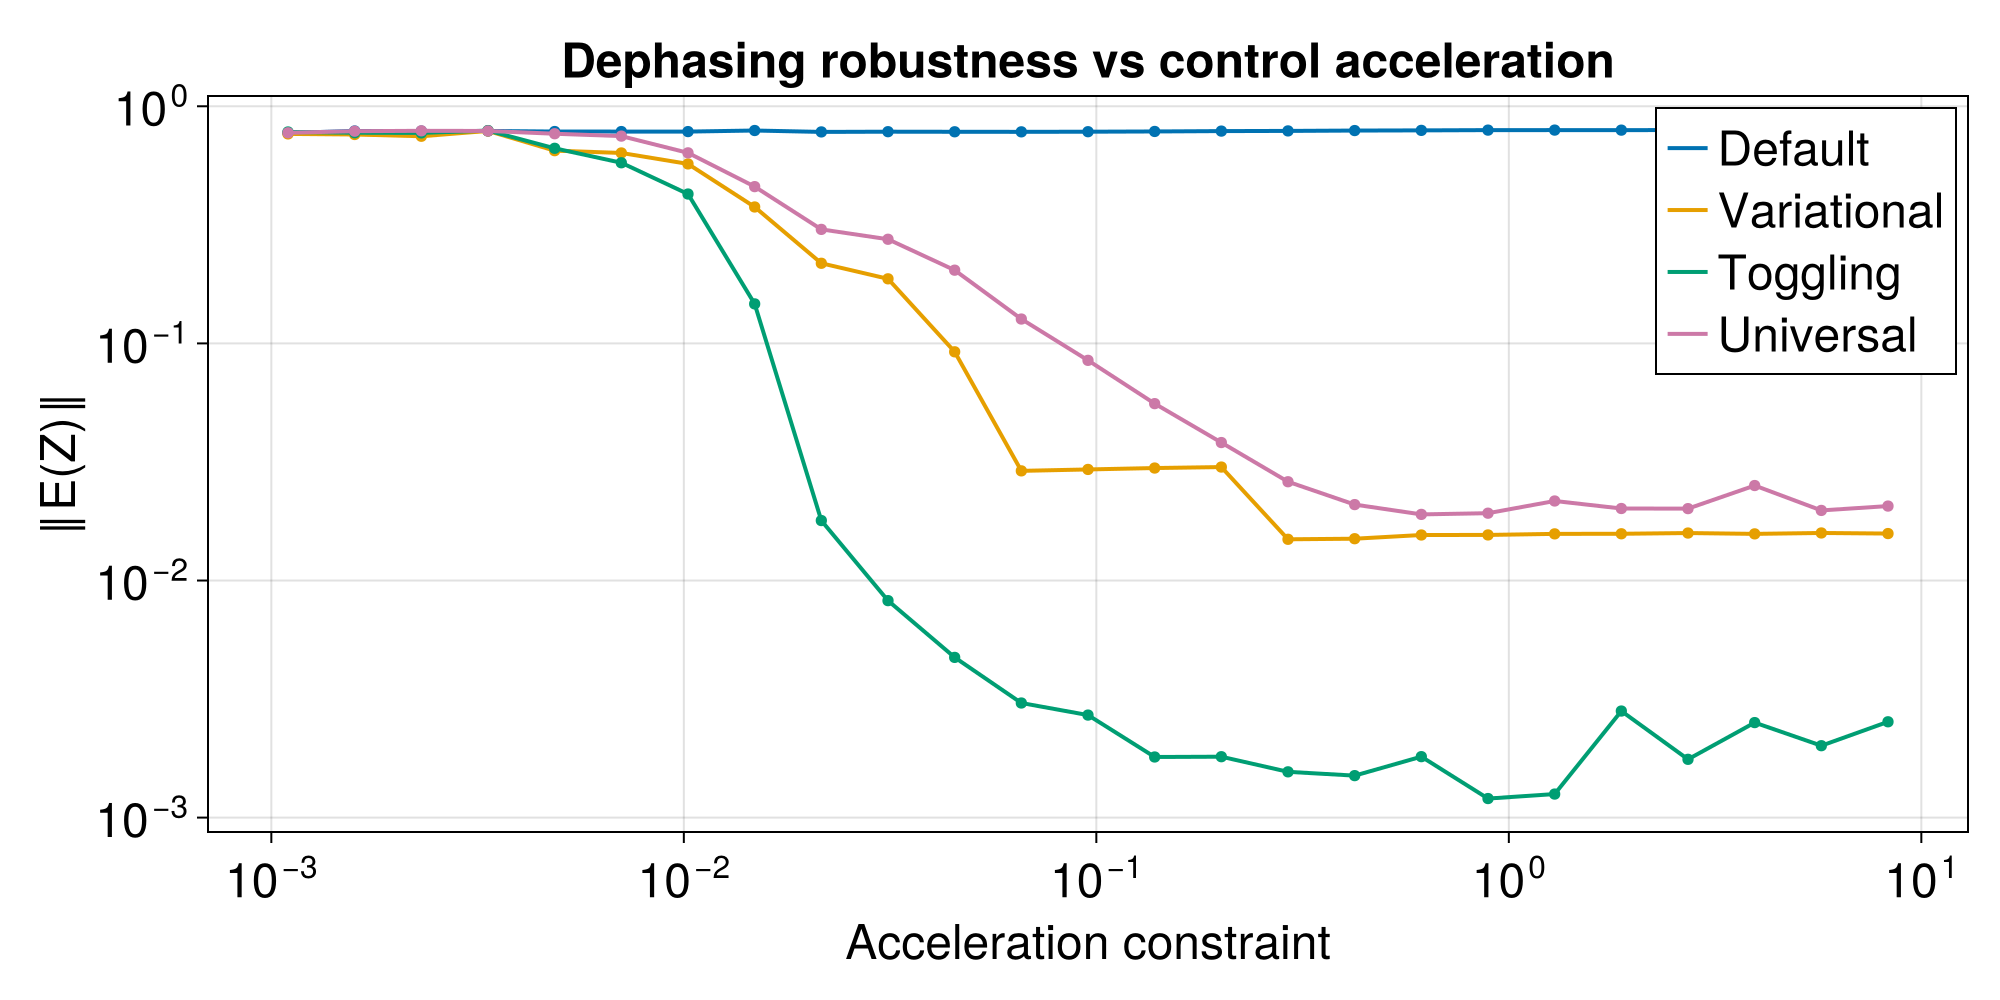

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


In [45]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:40
dfs = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs))
@assert all(x .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# ---------- Arithmetic mean across seeds ----------
mean_def = mean(Y_def; dims=2)[:]
mean_var = mean(Y_var; dims=2)[:]
mean_add = mean(Y_add; dims=2)[:]
mean_uni = mean(Y_uni; dims=2)[:]

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 500))
ax  = CM.Axis(fig[1, 1];
    xlabel = "Acceleration constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title  = "Dephasing robustness vs control acceleration",
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize  = 24,
    xticklabelsize = 24,
    yticklabelsize = 24,
)

# Plot only every 2nd point (1, 3, 5, ...)
const IDX = 2:4:length(x)

function draw!(y, color, label)
    CM.lines!(ax, x[IDX], y[IDX]; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x[IDX], y[IDX]; color=color, marker=:circle, markersize=8)
end

draw!(mean_def, colors[1], labels[1])
draw!(mean_var, colors[2], labels[2])
draw!(mean_add, colors[3], labels[3])
draw!(mean_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt, labelsize=24)

display(fig)
save("dda_constraint_dephasing_paper.png", fig; px_per_unit=2)

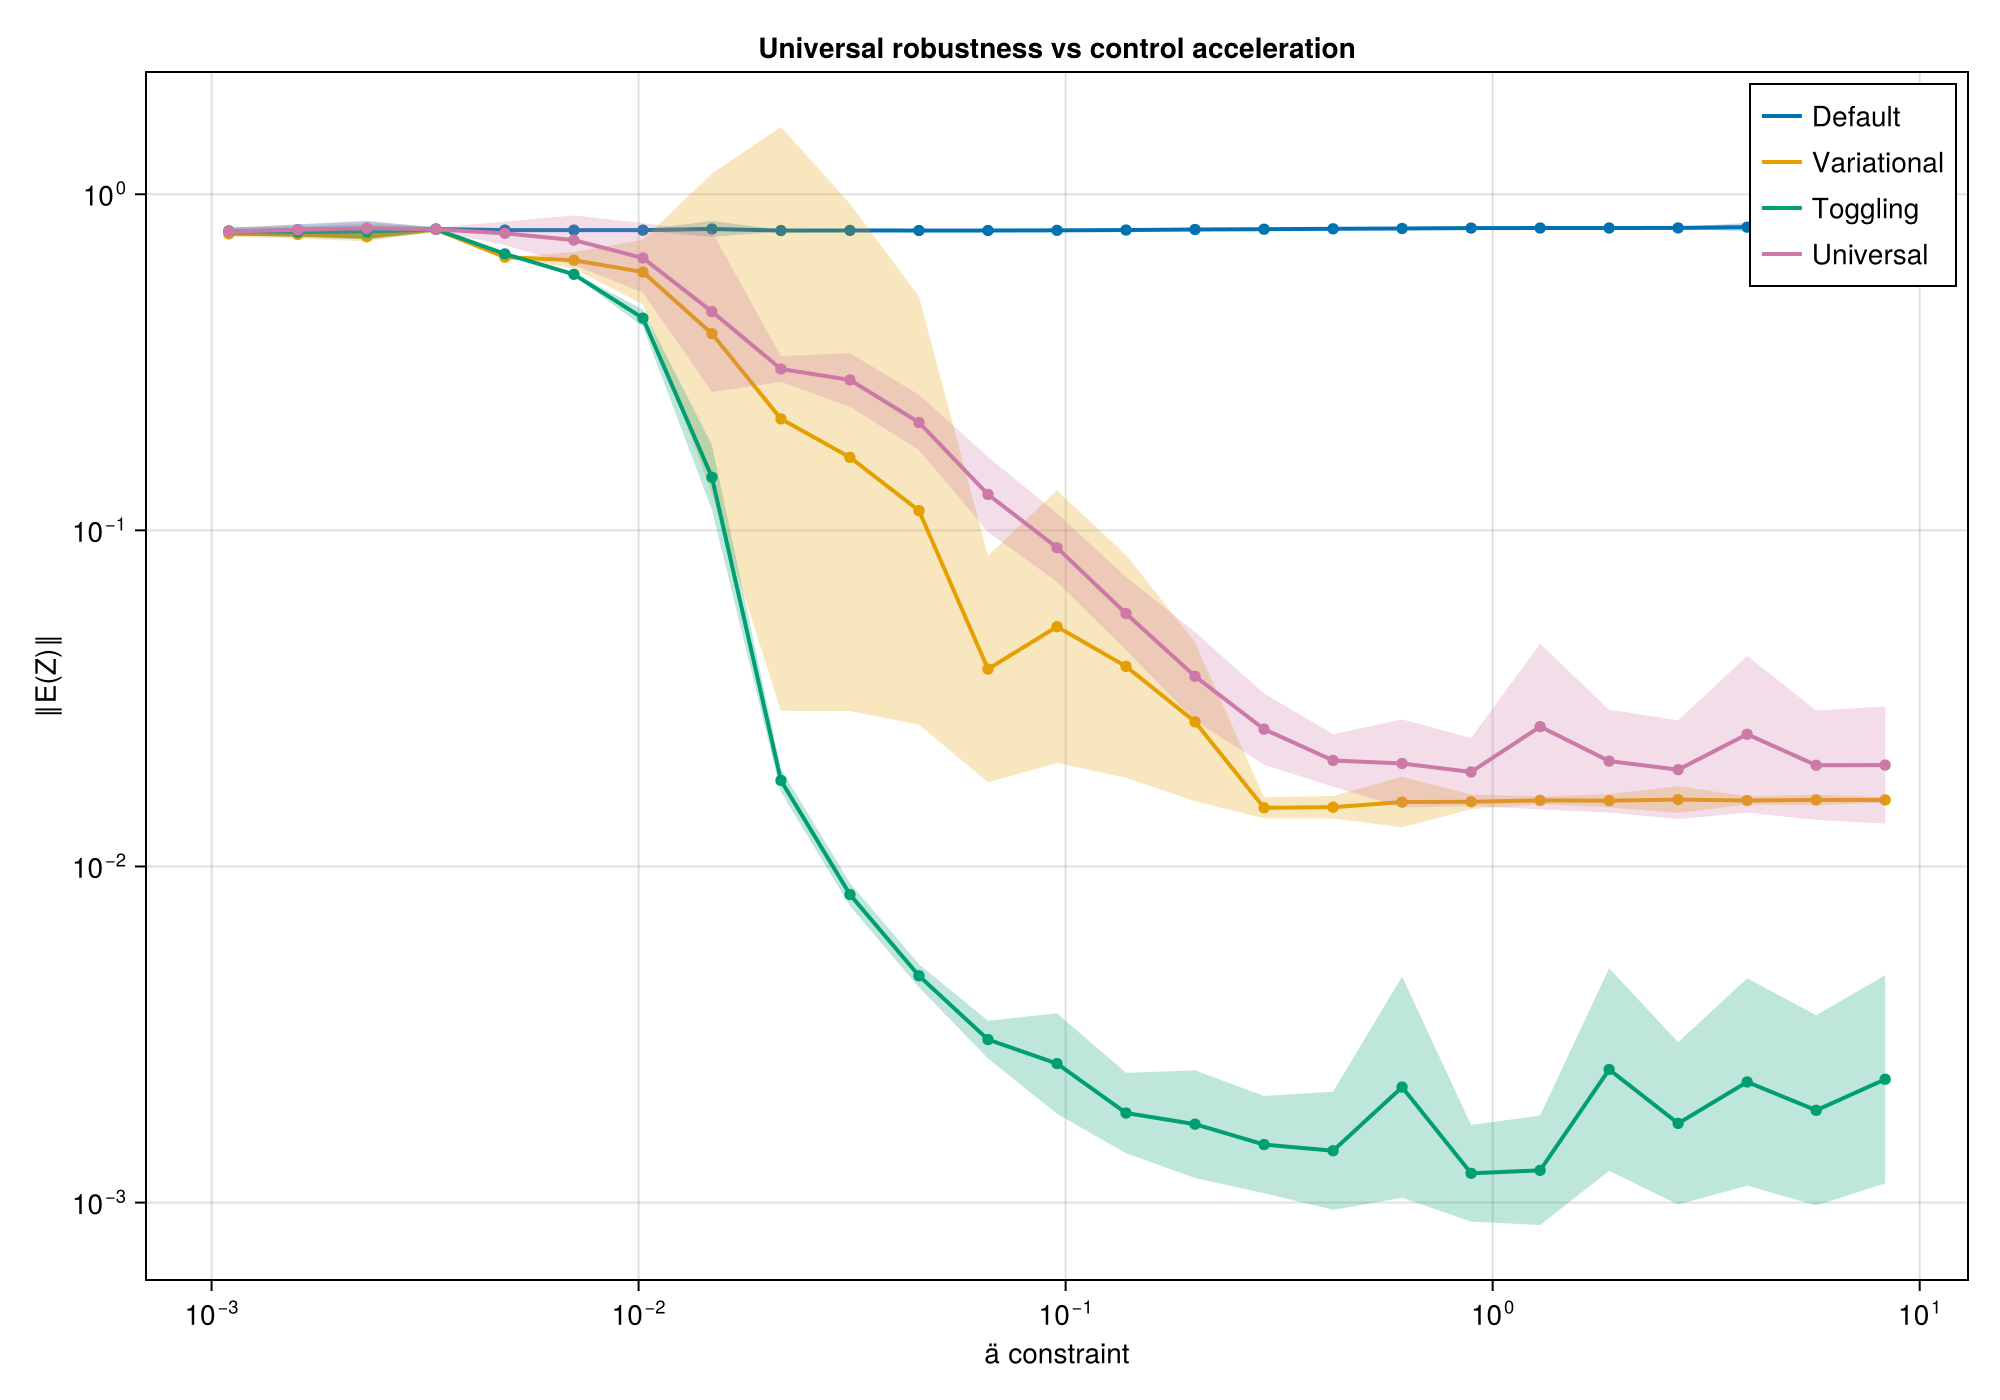

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [ ]:
using Pkg
Pkg.activate(".")

using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# ---------- Load data ----------
seed_range = 1:50
dfs = DataFrame[]
for i in seed_range
    fn = "dda_constraint_uni_data_dephasing_seed_$(i).csv"
    isfile(fn) && push!(dfs, CSV.read(fn, DataFrame))
end
@assert !isempty(dfs) "No CSV files were loaded."

# x (assumed identical across files and strictly positive)
x_all = collect(dfs[1].ä_vals)
@assert all(isequal(x_all), (collect(df.ä_vals) for df in dfs))
@assert all(x_all .> 0)

# Stack a column across seeds into an (n_x × n_seeds) matrix
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# ---------- Stats helper ----------
# We:
#   • keep only rows where ALL seeds are > 0 (needed for log scale)
#   • center line = arithmetic mean across seeds (your preference)
#   • band width = ± 1σ computed in log10 space (so uncertainty is symmetric on log scale)
#   • plot only every 4th point, starting from the 2nd (2, 6, 10, ...)
function series_stats_for_plot(x::AbstractVector, Y::AbstractMatrix)
    # mask rows valid for log scale
    row_ok = mapslices(r -> all(r .> 0), Y; dims=2)[:]
    x2 = x[row_ok]
    Y2 = Y[row_ok, :]

    # arithmetic mean (center line)
    μ = mean(Y2; dims=2)[:]

    # log-space std (for symmetric band on log axis)
    LY = log10.(Y2)
    σL = std(LY; dims=2)[:]

    # use μ as center, expand ±σ in log space around it
    μL  = log10.(μ)
    lo  = 10 .^ (μL .- σL)
    hi  = 10 .^ (μL .+ σL)

    # thin points: every 4th, starting at 2 (2, 6, 10, ...)
    idx_thin = 2:4:length(x2)

    return x2[idx_thin], μ[idx_thin], lo[idx_thin], hi[idx_thin]
end

x_def, μ_def, lo_def, hi_def = series_stats_for_plot(x_all, Y_def)
x_var, μ_var, lo_var, hi_var = series_stats_for_plot(x_all, Y_var)
x_add, μ_add, lo_add, hi_add = series_stats_for_plot(x_all, Y_add)
x_uni, μ_uni, lo_uni, hi_uni = series_stats_for_plot(x_all, Y_uni)

# ---------- Plot ----------
colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E(Z)‖",
    xscale = log10,
    yscale = log10,
    title  = "Universal robustness vs control acceleration",
)

# Draw helper: shaded band (±σ in log space) + line + dots, only at thinned x’s
function draw!(ax, x, μ, lo, hi, color, label)
    CM.band!(ax, x, lo, hi; color=(color, 0.25))
    CM.lines!(ax, x, μ; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, μ; color=color, marker=:circle, markersize=8)
end

draw!(ax, x_def, μ_def, lo_def, hi_def, colors[1], labels[1])
draw!(ax, x_var, μ_var, lo_var, hi_var, colors[2], labels[2])
draw!(ax, x_add, μ_add, lo_add, hi_add, colors[3], labels[3])
draw!(ax, x_uni, μ_uni, lo_uni, hi_uni, colors[4], labels[4])

CM.axislegend(ax; position=:rt)
display(fig)
# save("dda_constraint_dephasing_z_means_thinned_bands_log.png", fig; px_per_unit=2)

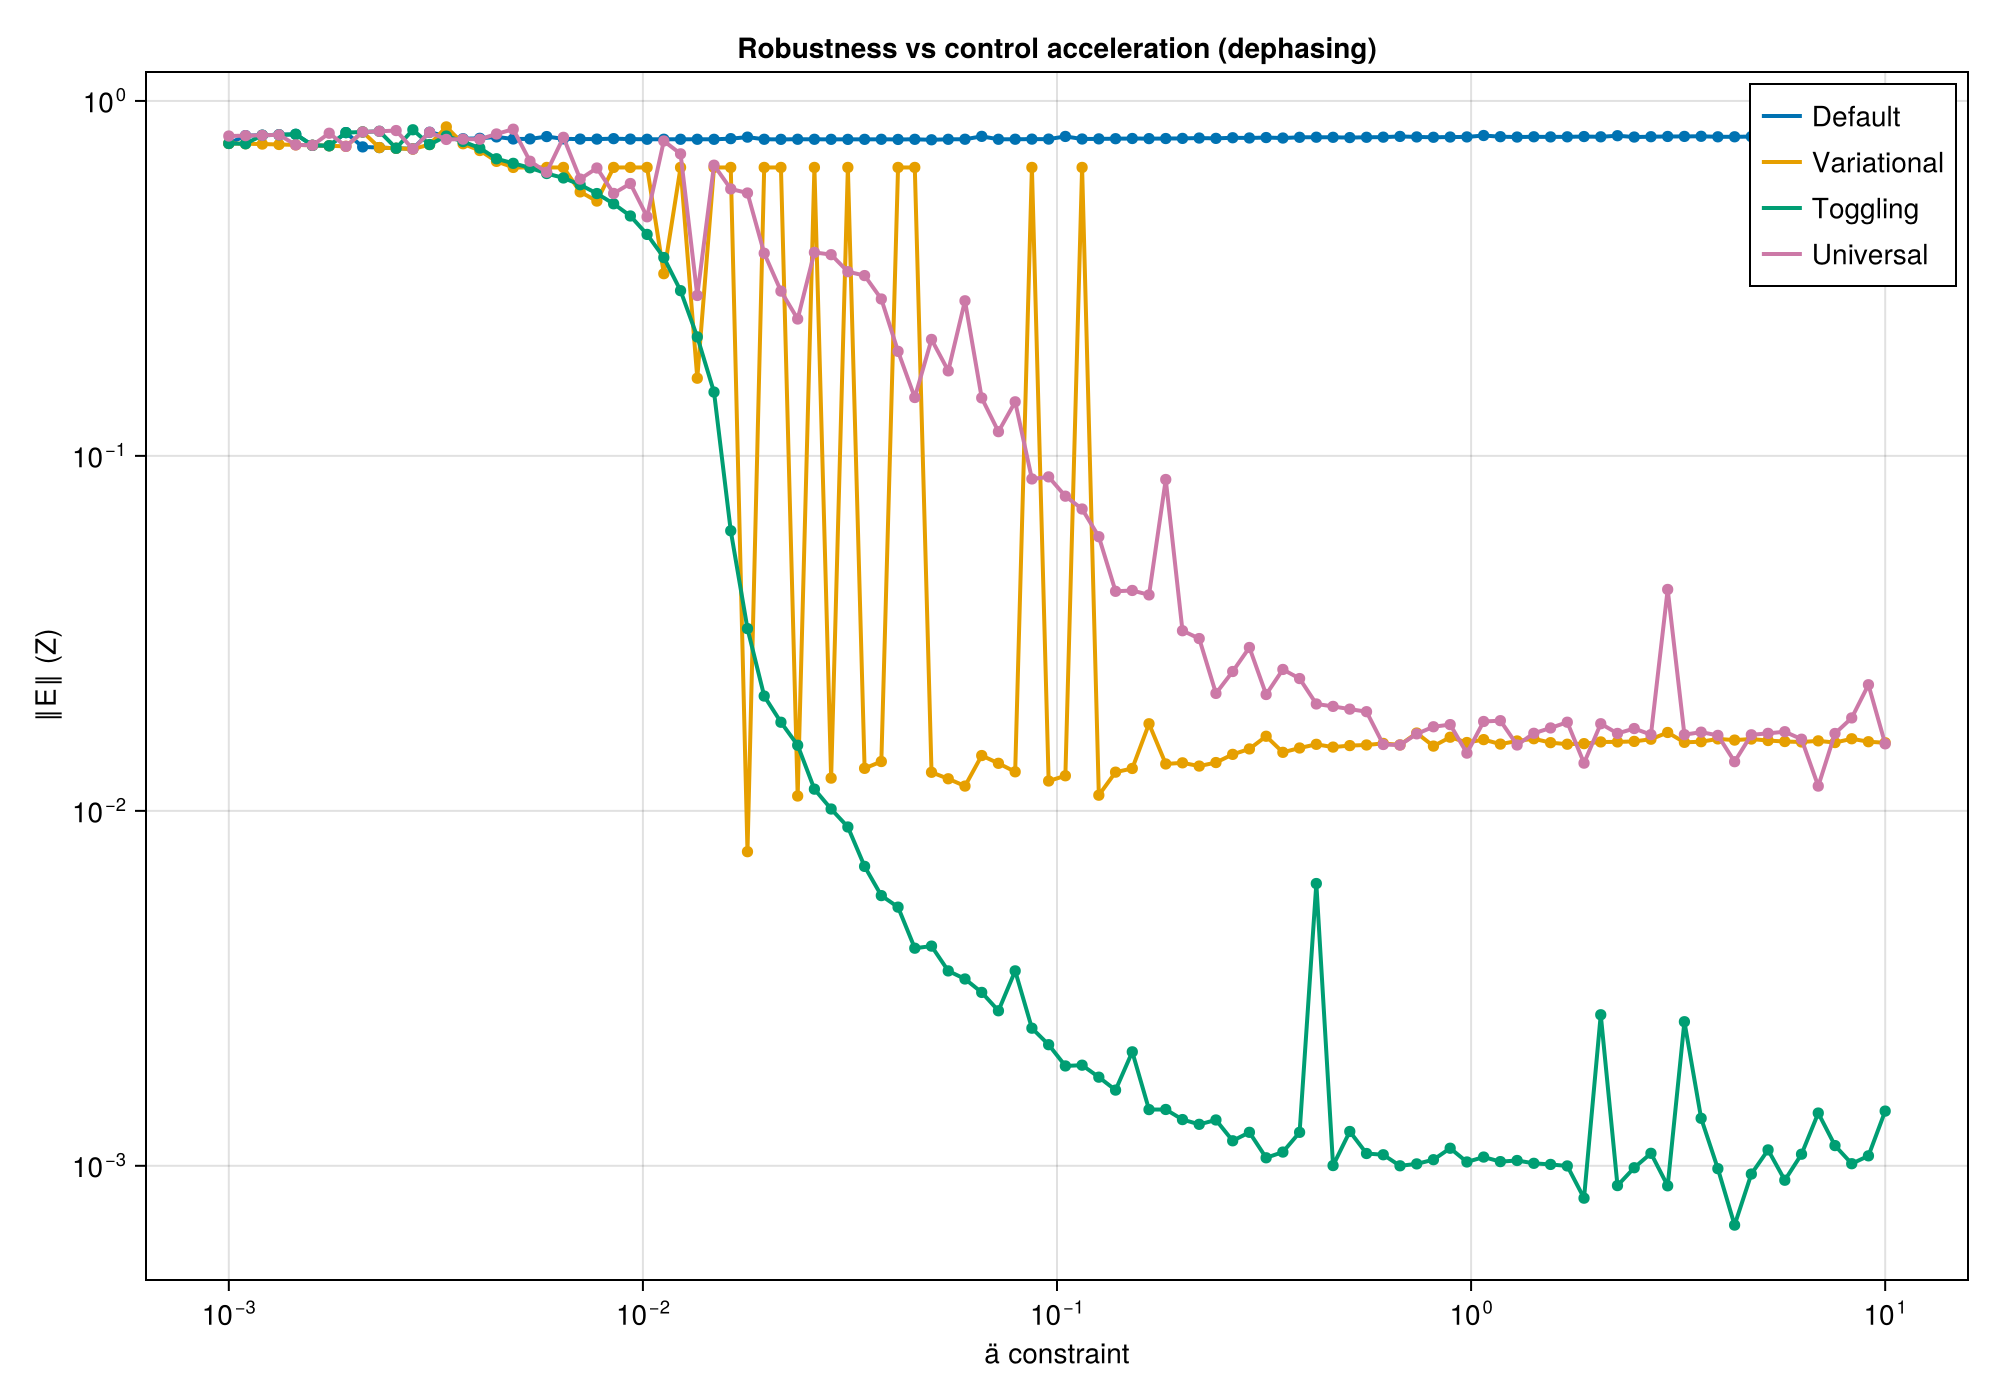

  Activating project at `~/Documents/GitHub/robust_control_sam/src`


CairoMakie.Screen{IMAGE}


In [5]:
using Pkg
Pkg.activate(".")
using CSV, DataFrames, Statistics
using CairoMakie
const CM = CairoMakie

# --- Load CSVs ---
seed_range = 1:1   # <-- right now only one file
dfs = DataFrame[]
for idx in seed_range
    fn = "dda_constraint_uni_data_dephasing_seed_$(idx).csv"
    if isfile(fn)
        push!(dfs, CSV.read(fn, DataFrame))
    else
        @warn "Missing $fn – skipping"
    end
end
@assert !isempty(dfs) "No CSV files were loaded."

# X values (assume same across files)
x = collect(dfs[1].ä_vals)
@assert all(isequal(x), (collect(df.ä_vals) for df in dfs)) "ä_vals differ across CSVs."

# Helper: stack a column across seeds into a matrix: (n_x, n_seeds)
stackcol(sym) = reduce(hcat, (df[!, sym] for df in dfs))

# Choose Z-channel (dephasing) columns (as in your snippet)
Y_def = stackcol(:norm_G_def_z)
Y_var = stackcol(:norm_G_var_z)
Y_add = stackcol(:norm_G_add_z)
Y_uni = stackcol(:norm_G_uni_z)

# --- Helpers ---
# mask rows where ALL values are > 0 (needed for log axes)
mask_log_ok(Y) = mapslices(r -> all(r .> 0), Y; dims=2)[:]

function draw_one!(ax, x, y; color, label)
    CM.lines!(ax, x, y; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x, y; color=color, marker=:circle, markersize=8)
end

function draw_many!(ax, x, Y; color, label)
    # mask rows where all seeds and x are positive
    row_ok = mask_log_ok(Y) .& (x .> 0)
    x2 = x[row_ok]
    Y2 = Y[row_ok, :]

    # geometric mean and ±1σ in log10 space
    LY = log10.(Y2)
    μL = mean(LY; dims=2)[:]     # mean in log space
    σL = std(LY;  dims=2)[:]     # std in log space

    μ  = 10 .^ μL
    lo = 10 .^ (μL .- σL)
    hi = 10 .^ (μL .+ σL)

    CM.band!(ax, x2, lo, hi; color=(color, 0.25))
    CM.lines!(ax, x2, μ; color=color, linewidth=2, label=label)
    CM.scatter!(ax, x2, μ; color=color, marker=:circle, markersize=8)
end

colors = Makie.wong_colors()
labels = ["Default", "Variational", "Toggling", "Universal"]

fig = CM.Figure(size = (1000, 700))
ax  = CM.Axis(fig[1, 1];
    xlabel = "ä constraint",
    ylabel = "‖E‖ (Z)",
    xscale = log10,
    yscale = log10,
    title  = "Robustness vs control acceleration (dephasing)",
)

if length(dfs) == 1
    # Single file: just plot lines + dots for each series
    # Mask out nonpositive rows to keep log scales happy
    row_ok_def = (x .> 0) .& (Y_def[:,1] .> 0)
    row_ok_var = (x .> 0) .& (Y_var[:,1] .> 0)
    row_ok_add = (x .> 0) .& (Y_add[:,1] .> 0)
    row_ok_uni = (x .> 0) .& (Y_uni[:,1] .> 0)

    draw_one!(ax, x[row_ok_def], Y_def[row_ok_def, 1]; color=colors[1], label=labels[1])
    draw_one!(ax, x[row_ok_var], Y_var[row_ok_var, 1]; color=colors[2], label=labels[2])
    draw_one!(ax, x[row_ok_add], Y_add[row_ok_add, 1]; color=colors[3], label=labels[3])
    draw_one!(ax, x[row_ok_uni], Y_uni[row_ok_uni, 1]; color=colors[4], label=labels[4])
else
    # Multiple files: draw mean curve + shaded ±σ band (in log space)
    draw_many!(ax, x, Y_def; color=colors[1], label=labels[1])
    draw_many!(ax, x, Y_var; color=colors[2], label=labels[2])
    draw_many!(ax, x, Y_add; color=colors[3], label=labels[3])
    draw_many!(ax, x, Y_uni; color=colors[4], label=labels[4])
end

CM.axislegend(ax; position = :rt)
display(fig)
# save("dda_constraint_dephasing_z_loglog.png", fig; px_per_unit=2)